## Грузим данные

In [1]:
from data_preparation import OzonDataFormer
from datetime import date

In [2]:
former = OzonDataFormer()

In [3]:
former.fit_text_vectorizer(feature_end_date=date(2024, 5, 31))

In [4]:
train_df = former.construct_dataset(
    feature_end_date=date(2024, 5, 31),
    target_start_date=date(2024, 6, 1),
    target_end_date=date(2024, 6, 30),
)

In [5]:
val_df = former.construct_dataset(
    feature_end_date=date(2024, 6, 30),
    target_start_date=date(2024, 7, 1),
    target_end_date=date(2024, 7, 31),
)

In [6]:
train_df = train_df.to_pandas()
X_train = train_df.drop(columns=['user_id', 'target']).sort_index(axis=1)
y_train = train_df['target']

In [7]:
val_df = val_df.to_pandas()
X_val = val_df.drop(columns=['user_id', 'target']).sort_index(axis=1)
y_val = val_df['target']

## Проверка адекватности разделения на тренировку и валидацию

In [8]:
cat_features = list(X_train.select_dtypes('category').columns) + list(X_train.select_dtypes('object').columns)

In [9]:
from catboost.utils import get_gpu_device_count

if get_gpu_device_count() > 0:
    task_type = 'GPU'
else:
    task_type = 'CPU'

params = {
    'iterations': 100,
    'depth': 7,
    'learning_rate': 0.05,
    'random_state': 1,
    'eval_metric': 'AUC',
    'loss_function': 'Logloss',
    'auto_class_weights': 'Balanced',
    'task_type': task_type,
    'cat_features': cat_features
}

In [10]:
from validation_check import get_train_val_difference

diff_score, _, _ = get_train_val_difference(X_train, y_train, X_val, y_val, params)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7918919	best: 0.7918919 (0)	total: 77.2ms	remaining: 7.64s
10:	test: 0.8076933	best: 0.8076933 (10)	total: 529ms	remaining: 4.28s
20:	test: 0.8102257	best: 0.8102257 (20)	total: 987ms	remaining: 3.71s
30:	test: 0.8111811	best: 0.8112235 (29)	total: 1.45s	remaining: 3.22s
40:	test: 0.8120709	best: 0.8120709 (40)	total: 1.91s	remaining: 2.75s
50:	test: 0.8125018	best: 0.8125018 (50)	total: 2.37s	remaining: 2.28s
60:	test: 0.8129603	best: 0.8129603 (60)	total: 2.83s	remaining: 1.81s
70:	test: 0.8132228	best: 0.8132228 (70)	total: 3.29s	remaining: 1.34s
80:	test: 0.8134255	best: 0.8134255 (80)	total: 3.74s	remaining: 878ms
90:	test: 0.8136404	best: 0.8136404 (90)	total: 4.19s	remaining: 414ms
99:	test: 0.8138507	best: 0.8138507 (99)	total: 4.61s	remaining: 0us
bestTest = 0.8138507307
bestIteration = 99


In [11]:
diff_score

0.709984390030013

Ну выглядит вроде адекватно учитывая что в данных очевидно есть временная зависимость

## Обучение модели

In [12]:
from catboost import CatBoostClassifier, Pool

In [13]:
train_pool = Pool(X_train, label=y_train, cat_features=cat_features)

val_pool = Pool(X_val, label=y_val, cat_features=cat_features)

In [14]:
params['iterations'] = 5000

model = CatBoostClassifier(**params)

In [15]:
try:
    model.load_model('./weird_shiet.bin')
except Exception:
    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True,
        verbose=10,
        early_stopping_rounds=50,
    )

In [16]:
model.save_model("weird_shiet.bin")

In [17]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

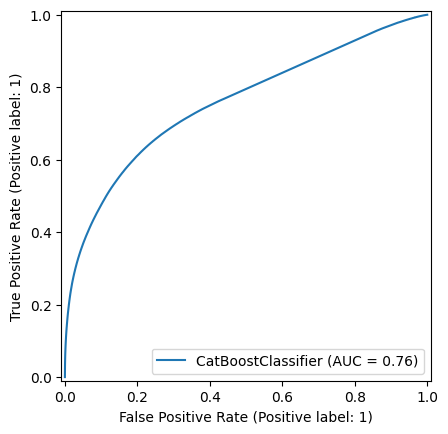

In [18]:
RocCurveDisplay.from_estimator(model, X_val, y_val)

## Интерпретация модели

In [19]:
from utils2 import AutoFeatureStandardizer, BinaryClassifierInterpreter
from cluster_compare import NotebookBinaryClusterInterpreter

In [20]:
import panel as pn
pn.extension()

In [21]:
# tool = NotebookBinaryClusterInterpreter(
#     X=X_train,
#     y=y_train,
# )
# tool.show()

In [22]:
interpreter = BinaryClassifierInterpreter(
    train=(X_train[::10], y_train[::10]),
    val=(X_val[::10], y_val[::10]),
    model=model
)

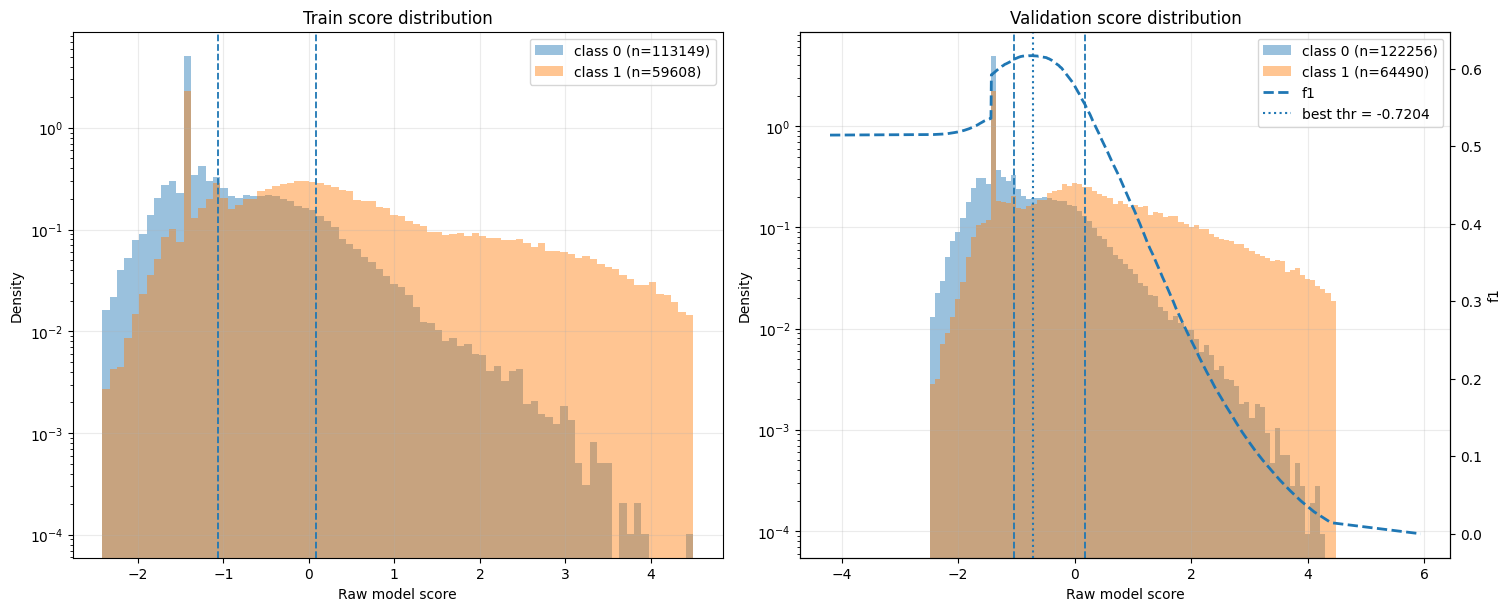

In [23]:
interpreter.plot_score_histograms_with_val_metric(val_metric_name="f1", use_log_density_y=True);

In [ ]:
interpreter.plot_float_feature_histograms()

In [25]:
interpreter.plot_score_feature_contours()

In [26]:
test_df = former.construct_dataset(
    feature_end_date=date(2024, 7, 31),
    users_df=former.test_users_submission,
)

In [32]:
test_df = test_df.to_pandas()

AttributeError: 'DataFrame' object has no attribute 'to_pandas'

In [33]:
test_df = test_df.sort_index(axis=1)

In [34]:
predict = model.predict(test_df.drop(columns='user_id'), prediction_type='RawFormulaVal')

In [35]:
from scipy.special import expit

In [36]:
probs = expit(predict)

In [37]:
import pandas as pd
import polars as pl

In [39]:
test_df['predict'] = probs
test_df[['user_id', 'predict']].to_csv('overfitted_ahh.csv', index=False)